In [1]:
from pathlib import Path
import pandas as pd

train_df = pd.read_csv('../dataframes/three_input_train_df.csv')
test_df = pd.read_csv('../dataframes/three_input_test_df.csv')
val_df = pd.read_csv('../dataframes/three_input_val_df.csv')

ROOT_DIR = Path.cwd().parent / 'cbis_ddsm_png'
print(Path.cwd())
print(ROOT_DIR)


c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\notebooks
c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png


In [2]:
train_df.head()

,patient_id,pathology,image file path,cropped image file path,ROI mask file path
0,P_00007,0,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00007,0,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_2/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_2/1.3.6.1.4.1.95...
4,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_3/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_3/1.3.6.1.4.1.95...


In [3]:
CACHE_ROOT = Path.cwd().parent / 'cbis-ddsm-cache'
CACHE_SIZE = 256

In [4]:
def search_1_png_file(image_file_path, root_dir):
    target_dir = root_dir / image_file_path
    png_files = list(target_dir.rglob("*.png"))
    return len(png_files) == 1


In [5]:
train_full_found = 0
train_full_missing = 0
train_missing_paths = []

for image_file_path in train_df["image file path"].dropna():
    if search_1_png_file(image_file_path, ROOT_DIR):
        train_full_found += 1
    else:
        train_full_missing += 1
        train_missing_paths.append(image_file_path)

print(f"Train Full Found: {train_full_found}")
print(f"Train Full Missing: {train_full_missing}")
print(train_missing_paths[:10])


print()

test_full_found = 0
test_full_missing = 0
test_missing_paths = []

for image_file_path in test_df["image file path"].dropna():
    if search_1_png_file(image_file_path, ROOT_DIR):
        test_full_found += 1
    else:
        test_full_missing += 1
        test_missing_paths.append(image_file_path)

print(f"Test Full Found: {test_full_found}")
print(f"Test Full Missing: {test_full_missing}")
print(test_missing_paths[:10])

print()

val_full_found = 0
val_full_missing = 0
val_missing_paths = []

for image_file_path in val_df["image file path"].dropna():
    if search_1_png_file(image_file_path, ROOT_DIR):
        val_full_found += 1
    else:
        val_full_missing += 1
        val_missing_paths.append(image_file_path)

print(f"Val Full Found: {val_full_found}")
print(f"Val Full Missing: {val_full_missing}")
print(val_missing_paths[:10])



Train Full Found: 2621
Train Full Missing: 233
['Calc-Training_P_00243_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.69417370012722895702437070491331483296/1.3.6.1.4.1.9590.100.1.2.19999280412338346012994175202802807368/', 'Calc-Training_P_00508_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.209851692411847809511355928473511548503/1.3.6.1.4.1.9590.100.1.2.279942441311681711935393514363630079570/', 'Calc-Training_P_01100_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.288490761312945132908392365044278247584/1.3.6.1.4.1.9590.100.1.2.396604500411307443204543930030203115880/', 'Calc-Training_P_01369_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.417471476711030742333130953103322924690/1.3.6.1.4.1.9590.100.1.2.295052506611946782011728928283174149536/', 'Mass-Training_P_00107_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.242410782311561910832870276222722704283/1.3.6.1.4.1.9590.100.1.2.19751888112560792610074441432332202668/', 'Mass-Training_P_00710_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.11724779811874427219879423151818034104/1.3.6.1.4.1.9590.100.1.2.3108029

In [6]:
train_df = train_df[train_df["image file path"].isin(train_missing_paths) == False]
test_df = test_df[test_df["image file path"].isin(test_missing_paths) == False]
val_df = val_df[val_df["image file path"].isin(val_missing_paths) == False]

len(train_df), len(test_df), len(val_df)

(2621, 326, 328)

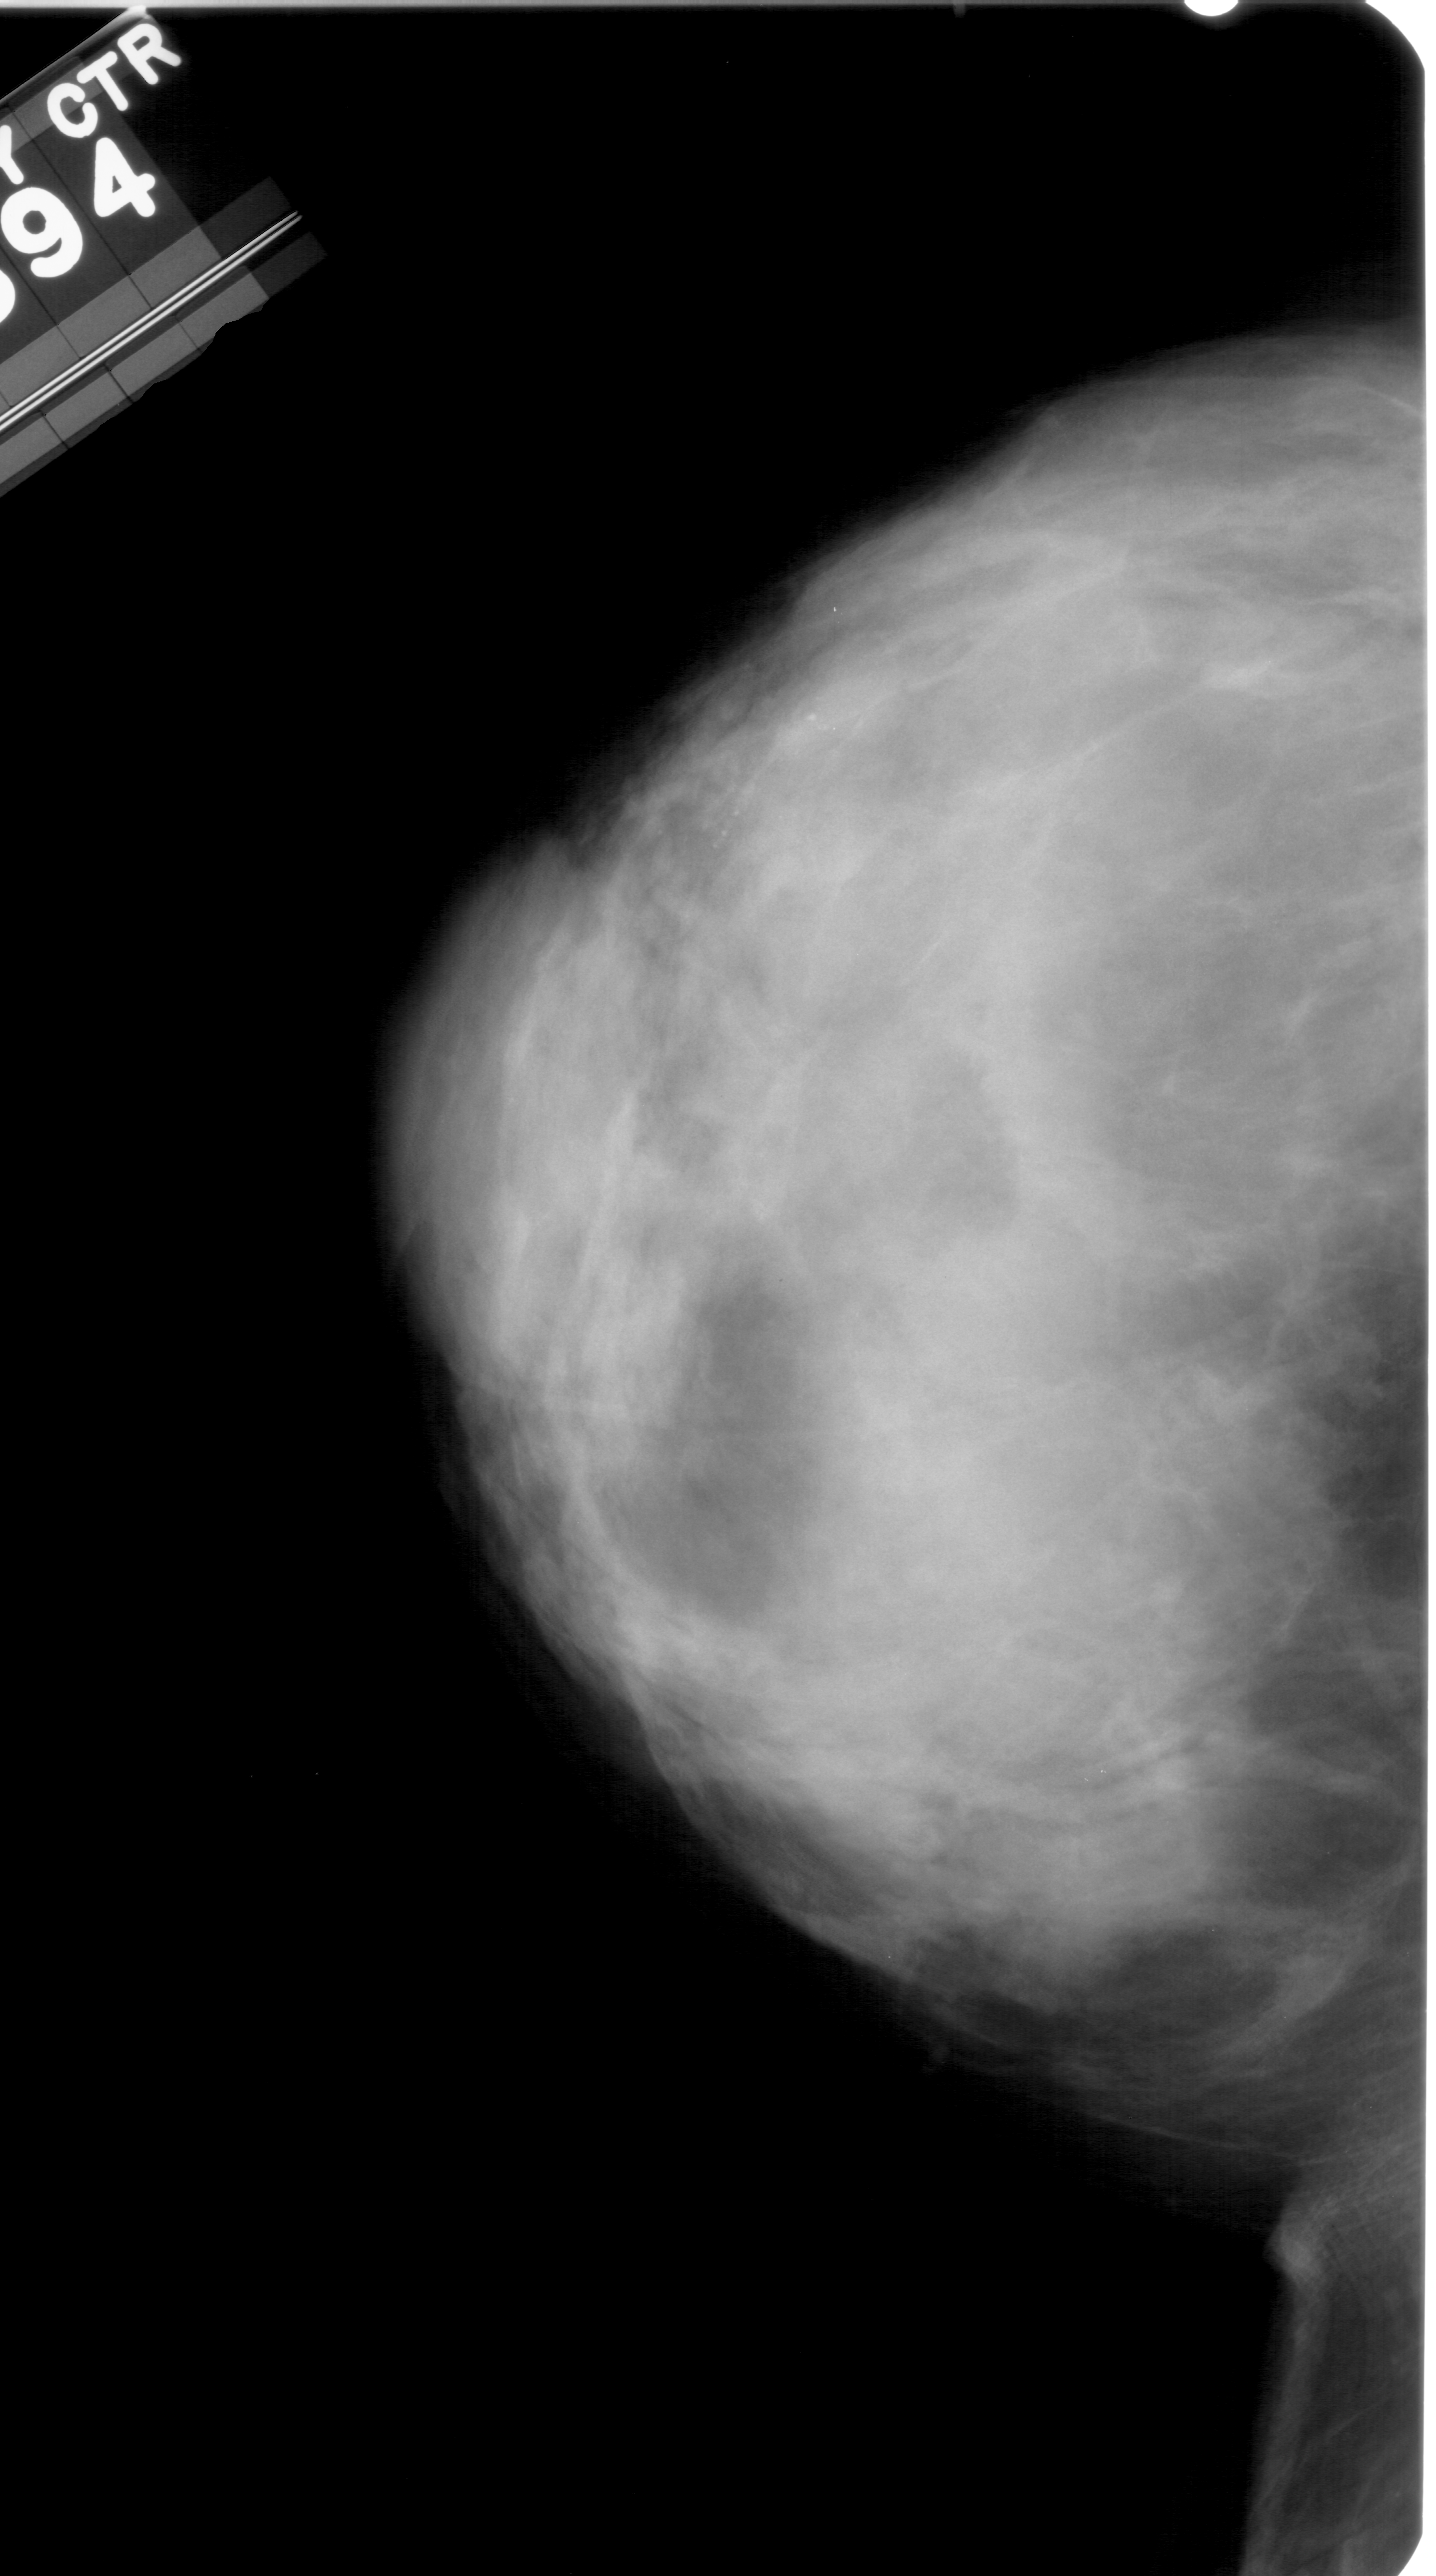

In [7]:
from PIL import Image
import pathlib

# 1. Get the absolute path
full_path = (ROOT_DIR / train_df["image file path"].iloc[0]).resolve()

image_path = next(full_path.glob("*.png"))

# 2. Add the Windows long-path prefix if it's a string, or convert pathlib
# Using str(full_path) with \\?\ forces Windows to accept deep paths
long_path = "\\\\?\\" + str(image_path)

# 3. Open the image
img = Image.open(long_path)

img

In [8]:
from pathlib import Path
from PIL import Image
import numpy as np
import os


def windows_long_path(path):
    """
    Adds the Windows long-path prefix if needed.
    """
    path = str(Path(path).resolve())

    if os.name == "nt" and not path.startswith("\\\\?\\"):
        path = "\\\\?\\" + path

    return path

In [9]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

def resolve_crop_path(crop_dir, root_dir):
    """
    Returns the relative path to the cropped mammogram PNG.

    Returns None if:
        - folder does not exist
        - folder has no PNGs
        - no cropped image could be identified
    """

    target_dir = Path(root_dir) / crop_dir

    if not target_dir.exists():
        return None

    png_files = list(target_dir.rglob("*.png"))

    if len(png_files) == 0:
        return None

    best_png = None
    max_unique = -1

    for png in png_files:
        try:
            img = Image.open(windows_long_path(png)).convert("L")
            arr = np.array(img)

            unique_values = len(np.unique(arr))

            if unique_values > max_unique:
                max_unique = unique_values
                best_png = png

        except Exception:
            continue

    if best_png is None:
        print(f"No valid PNG found for {crop_dir}")
        return None
    print(f"Best PNG for {crop_dir}: {best_png} with {max_unique} unique values")
    return str(best_png.relative_to(root_dir)).replace("\\", "/")

In [10]:
pd.set_option('display.max_colwidth', None)

In [11]:
train_df["cropped image file path"] = train_df["cropped image file path"].apply(
    lambda p: resolve_crop_path(p, ROOT_DIR)
)



Best PNG for Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.241202057913673145232234613012384759880/1.3.6.1.4.1.9590.100.1.2.314135871111943890422150247820137952041/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00007_LEFT_CC_1\1.3.6.1.4.1.9590.100.1.2.241202057913673145232234613012384759880\1.3.6.1.4.1.9590.100.1.2.314135871111943890422150247820137952041\6c7ea586-d2f5-4cc4-8f85-778279bf0a72.png with 244 unique values
Best PNG for Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.314250272911170289203882349024229868823/1.3.6.1.4.1.9590.100.1.2.91458279612485515203413781822560852485/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00007_LEFT_MLO_1\1.3.6.1.4.1.9590.100.1.2.314250272911170289203882349024229868823\1.3.6.1.4.1.9590.100.1.2.91458279612485515203413781822560852485\82ffd830-9912-48c7-a225-8dd460aa0d34.png with 242 unique values
Best PNG for C

In [23]:
test_df["cropped image file path"] = test_df["cropped image file path"].apply(
    lambda p: resolve_crop_path(p, ROOT_DIR)
)



Best PNG for Calc-Training_P_00012_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.277826312012567873540552331742789568935/1.3.6.1.4.1.9590.100.1.2.237853014212929374928763150281795876932/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00012_LEFT_CC_1\1.3.6.1.4.1.9590.100.1.2.277826312012567873540552331742789568935\1.3.6.1.4.1.9590.100.1.2.237853014212929374928763150281795876932\0fcd61ec-c4fc-42fc-b11f-d83a05d2803a.png with 223 unique values
Best PNG for Calc-Training_P_00012_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.78753198612199081812600833723126239399/1.3.6.1.4.1.9590.100.1.2.55891837611351185918415450910974994265/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00012_LEFT_MLO_1\1.3.6.1.4.1.9590.100.1.2.78753198612199081812600833723126239399\1.3.6.1.4.1.9590.100.1.2.55891837611351185918415450910974994265\07757c01-6b4c-4283-aabe-d092c52c1a65.png with 218 unique values
Best PNG for Cal

In [32]:
val_df["cropped image file path"] = val_df["cropped image file path"].apply(
    lambda p: resolve_crop_path(p, ROOT_DIR)
)



Best PNG for Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00005_RIGHT_CC_1\1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081\1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682\2442d64b-535e-4193-be98-9c096784e2f5.png with 219 unique values
Best PNG for Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.67512362210319636108148504382680781938/1.3.6.1.4.1.9590.100.1.2.296281207812130400303493285473798422894/: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\cbis_ddsm_png\Calc-Training_P_00005_RIGHT_MLO_1\1.3.6.1.4.1.9590.100.1.2.67512362210319636108148504382680781938\1.3.6.1.4.1.9590.100.1.2.296281207812130400303493285473798422894\875b6ecc-43a6-4894-9ad2-04c8051b2bf7.png with 256 unique values
Best PNG f

In [33]:
missing = val_df["cropped image file path"].isna().sum()

print(f"Missing cropped images: {missing}")

Missing cropped images: 0


In [24]:
missing = test_df["cropped image file path"].isna().sum()

print(f"Missing cropped images: {missing}")

Missing cropped images: 0


In [12]:
missing = train_df["cropped image file path"].isna().sum()

print(f"Missing cropped images: {missing}")

Missing cropped images: 22


In [13]:
missing_rows = train_df[train_df["cropped image file path"].isna()]

print(missing_rows[[
    "image file path",
    "cropped image file path"
]])

                                                                                                                                                        image file path  \
809    Calc-Training_P_01307_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.244685245212927958608794377293232996693/1.3.6.1.4.1.9590.100.1.2.261162329911495677136618643691703402020/   
818    Calc-Training_P_01321_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.23092099312957484832960989740759360488/1.3.6.1.4.1.9590.100.1.2.241020638813027313501928349840148500619/   
1701  Mass-Training_P_00815_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.342424163312992923910140650262607753187/1.3.6.1.4.1.9590.100.1.2.131861114610888161822097220104193388621/   
1892  Mass-Training_P_01163_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.113402764512980354107986426232156723781/1.3.6.1.4.1.9590.100.1.2.181141325510810457226714664113141838012/   
2319        Calc-Test_P_00141_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.178857961212194190028926752161715518449/1.3.6.1.4.1.9590.100.1.2.31530197011146306

In [14]:
train_df = train_df[train_df["cropped image file path"].notna()]

In [17]:
train_df.isnull().sum()

patient_id                 0
pathology                  0
image file path            0
cropped image file path    0
ROI mask file path         0
dtype: int64

In [18]:
len(train_df)

2599

In [15]:
from pathlib import Path

def resolve_full_image_path(image_dir, root_dir):
    """
    Resolves a full mammogram directory to its PNG file.

    Returns:
        Relative path to the PNG if found.
        None if the directory doesn't exist or contains no PNG.
    """

    target_dir = Path(root_dir) / image_dir

    if not target_dir.exists():
        return None

    png_files = list(target_dir.rglob("*.png"))

    if len(png_files) == 0:
        return None

    if len(png_files) > 1:
        print(f"Warning: Multiple PNGs found in {target_dir}. Using the first one.")

    png = png_files[0]

    return str(png.relative_to(root_dir)).replace("\\", "/")

In [16]:
train_df["image file path"] = (
    train_df["image file path"]
    .apply(lambda p: resolve_full_image_path(p, ROOT_DIR))
)

In [21]:
train_df.drop(columns=["ROI mask file path"], inplace=True)

In [22]:
train_df.head()

,patient_id,pathology,image file path,cropped image file path
0,P_00007,0,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.201322325113694962619881476352450072222/1.3.6.1.4.1.9590.100.1.2.228699627313487111012474405462022068297/d6536189-e9ad-49c7-8195-f4159f22ca3c.png,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.241202057913673145232234613012384759880/1.3.6.1.4.1.9590.100.1.2.314135871111943890422150247820137952041/6c7ea586-d2f5-4cc4-8f85-778279bf0a72.png
1,P_00007,0,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.370479499712916693322010643793108454887/1.3.6.1.4.1.9590.100.1.2.104743410411133110629448544090466900446/eb181cf5-3703-4280-b9e0-f38557614848.png,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.314250272911170289203882349024229868823/1.3.6.1.4.1.9590.100.1.2.91458279612485515203413781822560852485/82ffd830-9912-48c7-a225-8dd460aa0d34.png
2,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.162256682111885666305889708873412464189/1.3.6.1.4.1.9590.100.1.2.406725628213826290127343763811145520834/beb4a6cf-b56b-4ce8-a0eb-6cc093b34d4e.png,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.336811694512764490002272925921108351157/1.3.6.1.4.1.9590.100.1.2.281397494612871934937455783843630775495/cc2ac0cd-e861-4a04-96b9-3c4ff5ce9a04.png
3,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.162256682111885666305889708873412464189/1.3.6.1.4.1.9590.100.1.2.406725628213826290127343763811145520834/beb4a6cf-b56b-4ce8-a0eb-6cc093b34d4e.png,Calc-Training_P_00008_LEFT_CC_2/1.3.6.1.4.1.9590.100.1.2.207558519313356140106496367610041842177/1.3.6.1.4.1.9590.100.1.2.2024181113538627406890441552979568519/1abe36a0-00b6-4466-af67-124a863b3cfa.png
4,P_00008,0,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.162256682111885666305889708873412464189/1.3.6.1.4.1.9590.100.1.2.406725628213826290127343763811145520834/beb4a6cf-b56b-4ce8-a0eb-6cc093b34d4e.png,Calc-Training_P_00008_LEFT_CC_3/1.3.6.1.4.1.9590.100.1.2.74480335312443720440103727953726257477/1.3.6.1.4.1.9590.100.1.2.358964325411863896506852883280957478483/24d0b225-f083-4964-8498-11d7236790c5.png


In [25]:
train_df.to_csv('../dataframes/two_input_train_df_cleaned.csv', index=False)

In [28]:
test_df["image file path"] = (
    test_df["image file path"]
    .apply(lambda p: resolve_full_image_path(p, ROOT_DIR))
)

In [30]:
test_df.drop(columns=["ROI mask file path"], inplace=True)

In [31]:
test_df.to_csv('../dataframes/two_input_test_df_cleaned.csv', index=False)

In [36]:
val_df["image file path"] = (
    val_df["image file path"]
    .apply(lambda p: resolve_full_image_path(p, ROOT_DIR))
)

In [37]:
val_df.drop(columns=["ROI mask file path"], inplace=True)

In [39]:
val_df.to_csv('../dataframes/two_input_val_df_cleaned.csv', index=False)